# Fire Detection — Results Analysis

Loads `results/metrics.csv` produced by `src/evaluate.py` and plots a side-by-side
comparison of **F1 score** and **average FPS** for both detectors.

> **Pre-requisite:** Run `python src/evaluate.py` first to generate the CSV.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

# Resolve path relative to repo root regardless of where Jupyter is launched
REPO_ROOT = Path("__file__").resolve().parent.parent
METRICS_PATH = REPO_ROOT / "results" / "metrics.csv"

# Fallback: look one level up from the notebook directory
if not METRICS_PATH.exists():
    METRICS_PATH = Path("../results/metrics.csv")

df = pd.read_csv(METRICS_PATH)
df

,detector,precision,recall,f1,avg_fps,tp,fp,fn
0,HSV Baseline,0.6739,0.4663,0.5512,841.07,1730,837,1980
1,Hybrid (HSV + MobileNetV2),0.5761,0.6143,0.5946,57.20,2279,1677,1431


Chart saved to /Users/nsethi/Downloads/projects/fire-detection-research/results/comparison_chart.png


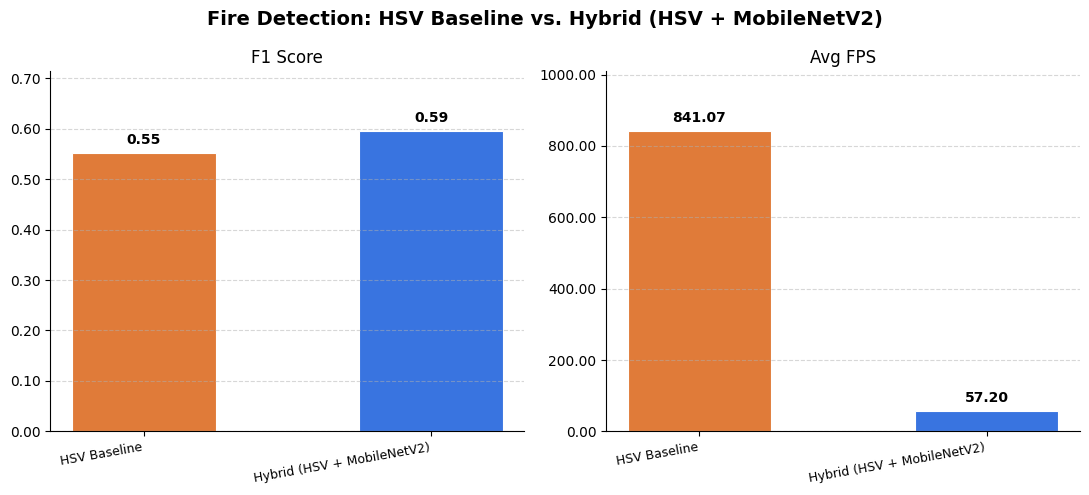

In [2]:
# -------------------------------------------------------------------------
# Bar chart: F1 and average FPS side-by-side for each detector
# -------------------------------------------------------------------------

metrics_to_plot = ["f1", "avg_fps"]
metric_labels   = ["F1 Score", "Avg FPS"]

detectors = df["detector"].tolist()
x = np.arange(len(detectors))
bar_width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Fire Detection: HSV Baseline vs. Hybrid (HSV + MobileNetV2)", fontsize=14, fontweight="bold")

colors = ["#E07B39", "#3974E0"]  # orange for HSV-ish, blue for hybrid

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    values = df[metric].tolist()
    bars = ax.bar(x, values, color=colors[:len(detectors)], width=0.5, edgecolor="white", linewidth=0.8)

    # Annotate bars with their values
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

    ax.set_title(label, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(detectors, rotation=10, ha="right", fontsize=9)
    ax.set_ylim(0, max(values) * 1.2 if max(values) > 0 else 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
output_fig = Path("../results/comparison_chart.png")
plt.savefig(output_fig, dpi=150, bbox_inches="tight")
print(f"Chart saved to {output_fig.resolve()}")
plt.show()

In [3]:
# -------------------------------------------------------------------------
# Precision / Recall breakdown table
# -------------------------------------------------------------------------

display_cols = ["detector", "precision", "recall", "f1", "avg_fps", "tp", "fp", "fn"]
df[display_cols].style \
    .format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "avg_fps": "{:.1f}"}) \
    .background_gradient(subset=["f1"], cmap="YlOrRd") \
    .set_caption("Detector Comparison — Aggregated Across All Test Videos")

,detector,precision,recall,f1,avg_fps,tp,fp,fn
0,HSV Baseline,0.674,0.466,0.551,841.1,1730,837,1980
1,Hybrid (HSV + MobileNetV2),0.576,0.614,0.595,57.2,2279,1677,1431


## Interpretation notes

- **F1** is the harmonic mean of precision and recall — the primary metric for imbalanced
  detection tasks where both false alarms and missed detections matter.
- **Avg FPS** measures throughput on the evaluation machine; the Hybrid detector's FPS
  degrades gracefully relative to fire-frame density (more fire → more NN calls → lower FPS).
- If Hybrid F1 < HSV F1, check the `hsv_gate_threshold` in `hybrid_detector.py` —
  it may be too high, causing the NN to be skipped on borderline frames.